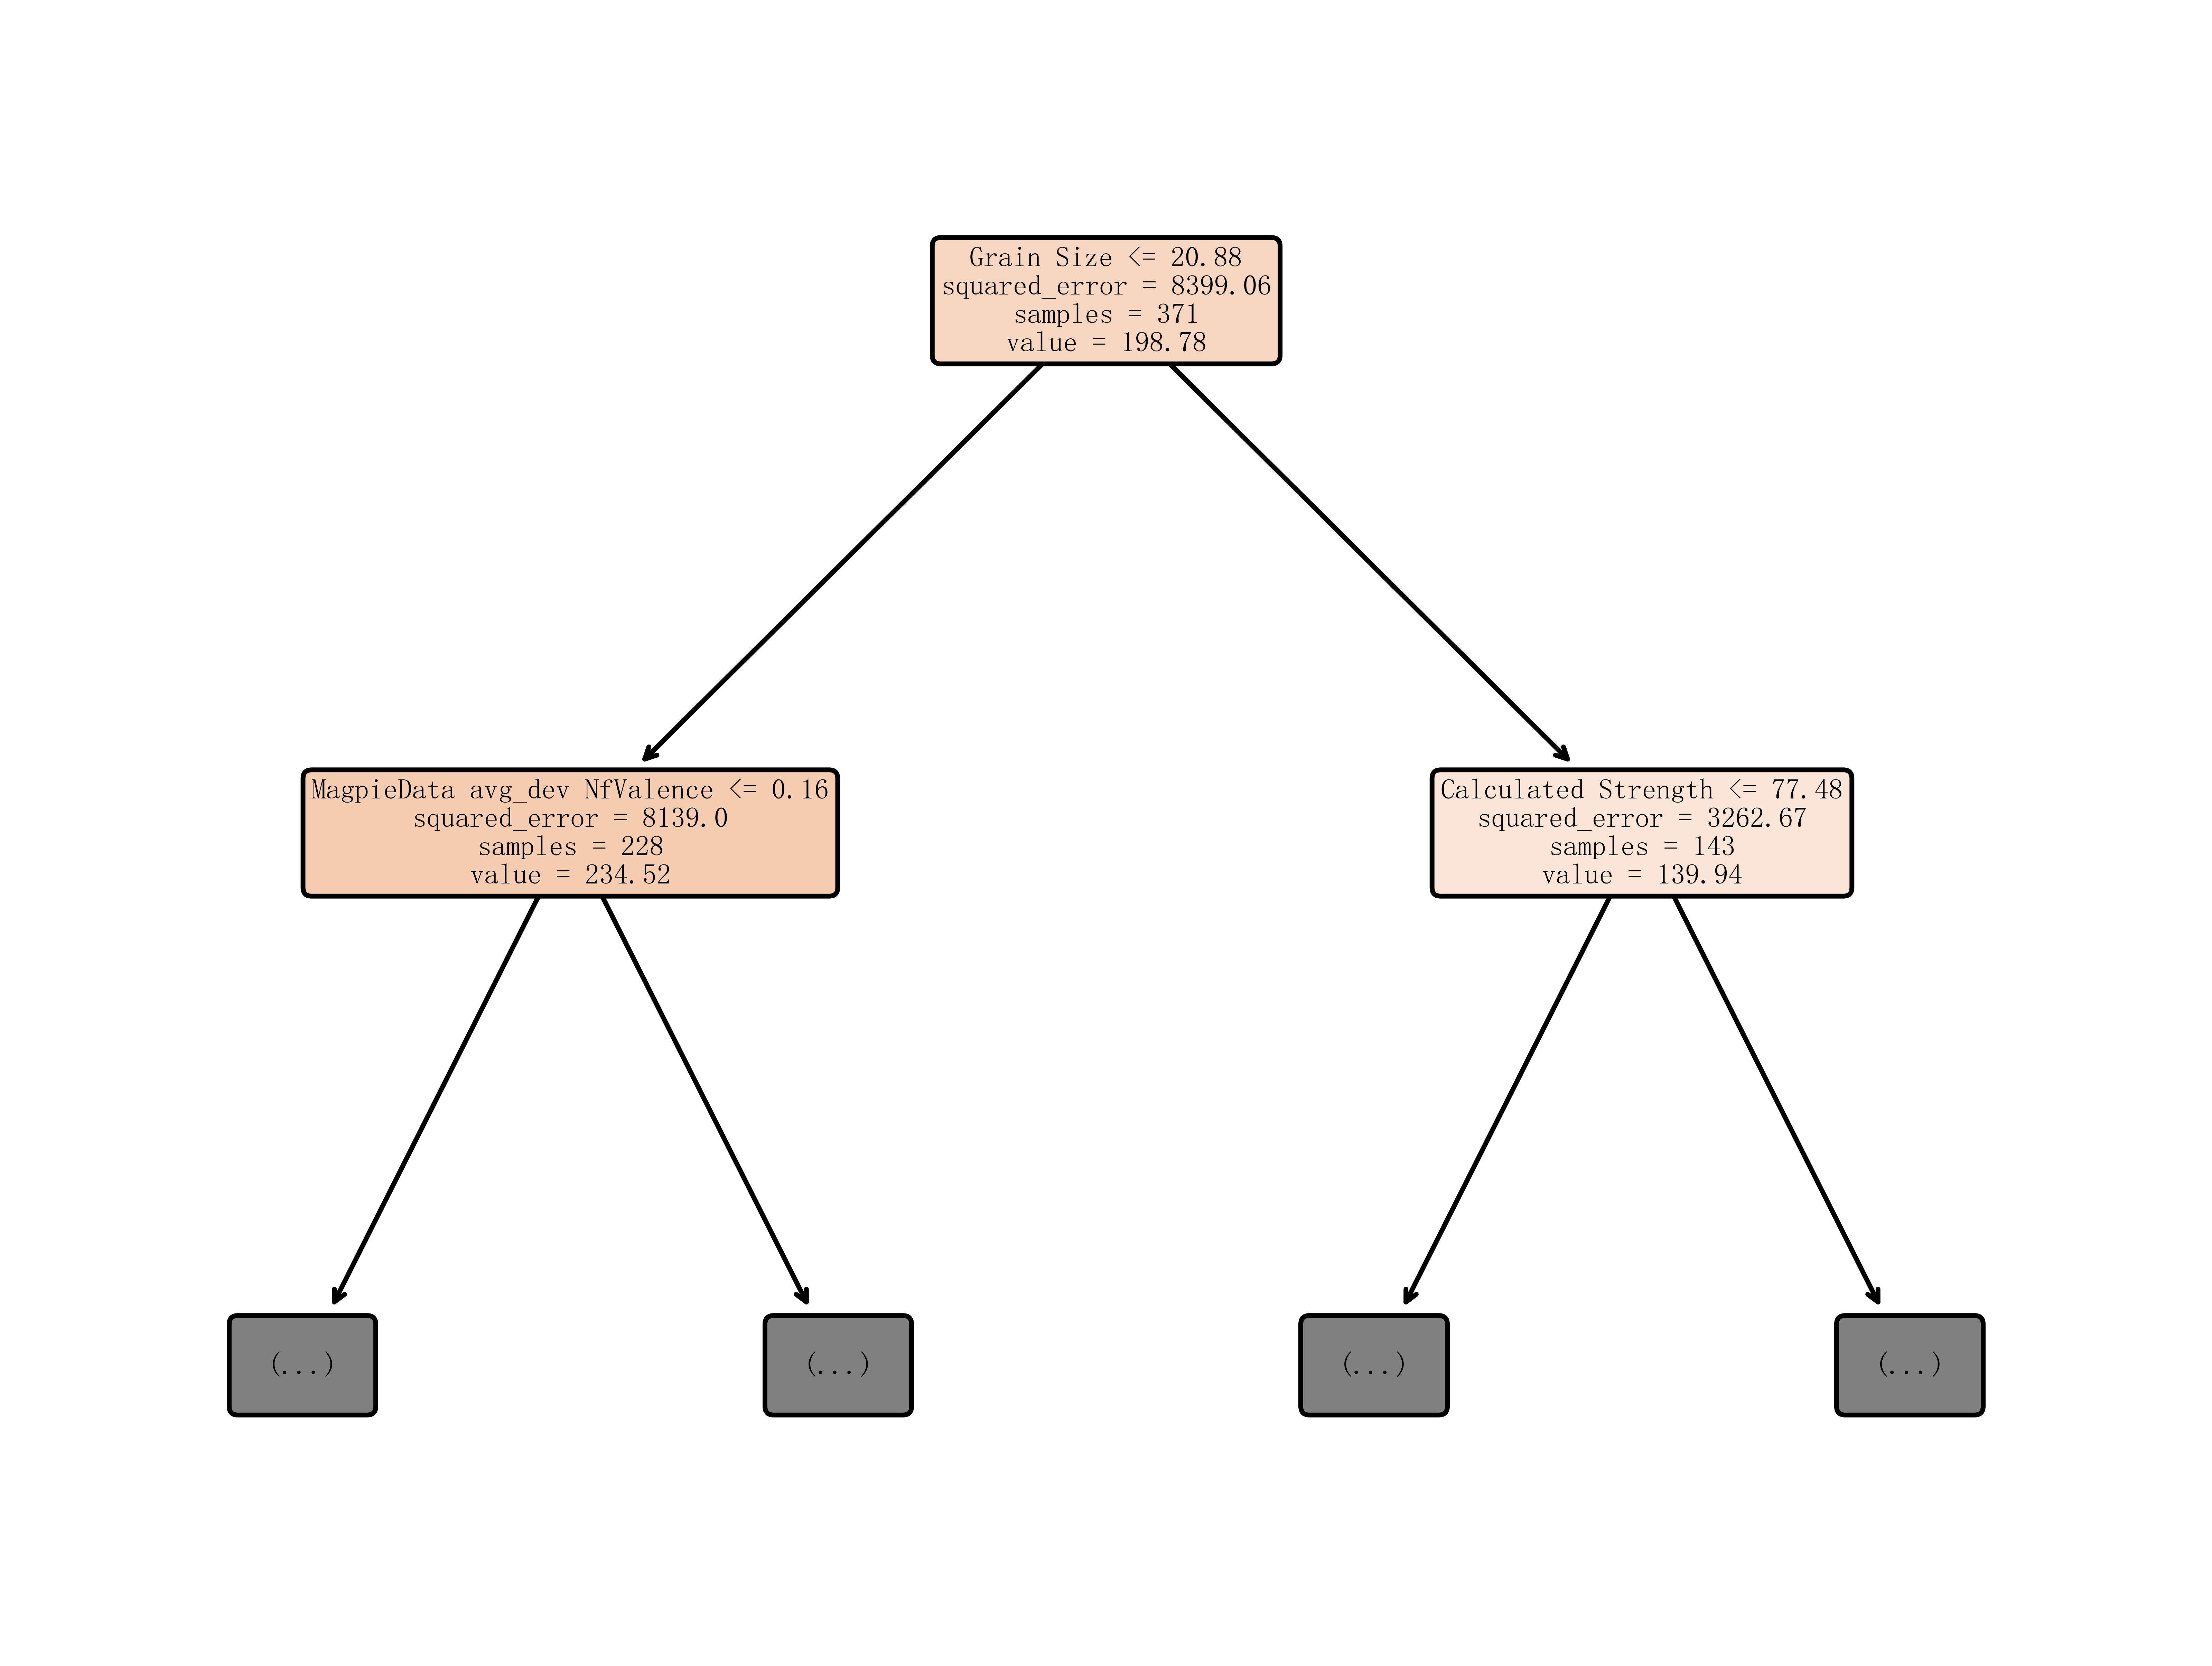

Node0, depth 0: Grain Size <= 20.88
  -> samples: 371, value: [[198.77540678]]
  Node1, depth 1: MagpieData avg_dev NfValence <= 0.16
    -> samples: 228, value: [[234.52356948]]
    Node2, depth 2: Calculated Strength <= 202.61
      -> samples: 180, value: [[209.18631757]]
      Node3, depth 3: MagpieData mean AtomicWeight <= 24.66
        -> samples: 88, value: [[176.22764706]]
        Node4, depth 4: Mixing enthalpy <= 0.23
          -> samples: 62, value: [[194.42061856]]
          Node5, depth 5: MagpieData range AtomicWeight <= 16.65
            -> samples: 38, value: [[174.51851852]]
            Node6, depth 6: MagpieData avg_dev NValence <= 0.01
              -> samples: 4, value: [[94.275]]
              Leaf7, depth 7: samples = 2, value = [[63.55]]
              Node8, depth 7: Calculated Grain Boundary <= 54.50
                -> samples: 2, value: [[125.]]
                Leaf9, depth 8: samples = 1, value = [[110.]]
                Leaf10, depth 8: samples = 1, value = [

In [2]:
import numpy as np
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

rf = joblib.load('../Final_Model/models/qf/rf/rf1.pkl')
df = pd.read_excel('../Final_Model/Full.xlsx', index_col=0)  # 引入这一列之后，原本的第一列就是一个索引，第0列会从有意义的列开始
# 删除包含空值的行

df = df[df['屈服强度'] != 0].reset_index(drop=True)
feature_names = df.columns[:-4]  # 特征名为屈服强度（倒数第四列）之前的部分

X = df.iloc[:, :-4]  # 特征: 最后四列之前的所有列
y = df['屈服强度']  # 目标: 倒数第四列
# 获取随机森林中的第一个树
tree = rf.estimators_[0]
# 可视化
plt.rcParams['font.sans-serif'] = ['SimSun']  # 设置中文字体为宋体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号'-'显示为方块的
plt.figure(figsize=(8,6),dpi = 1000)
plot_tree(tree, filled=True, feature_names=feature_names, rounded=True, precision=2,max_depth = 1)
plt.savefig('rf1_tree0.png')
plt.show()


# 结构化细节展示
from sklearn.tree import DecisionTreeClassifier, _tree
import numpy as np

# 假设你已经有一个训练好的决策树模型 'tree'
# 以下是遍历决策树并打印每个节点信息的函数

def print_tree(tree, feature_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    def recurse(node, depth):
        indent = "  " * depth
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            samples = tree_.n_node_samples[node]
            values = tree_.value[node]
            print(f"{indent}Node{node}, depth {depth}: {name} <= {threshold:.2f}")
            print(f"{indent}  -> samples: {samples}, value: {values}")
            recurse(tree_.children_left[node], depth + 1)
            recurse(tree_.children_right[node], depth + 1)
        else:
            samples = tree_.n_node_samples[node]
            values = tree_.value[node]
            print(f"{indent}Leaf{node}, depth {depth}: samples = {samples}, value = {values}")

    recurse(0, 0)

# 使用此函数查看树的结构
print_tree(tree, feature_names=feature_names)



In [19]:
# 获取所有模型的根节点
import joblib
def print_root_nodes(model_path, feature_names):
    # 加载模型
    with open(model_path, 'rb') as file:
        rf = joblib.load(file)

    # 遍历随机森林中的每棵树
    for idx, tree in enumerate(rf.estimators_):
        tree_ = tree.tree_
        # print(tree_.feature)
        # feature_name = [
        #     feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!" for i in tree_.feature
        # ]
        
        # 仅考虑根节点
        node = 0
        name = feature_names[tree_.feature[node]]
        threshold = tree_.threshold[node]
        left_child = tree_.children_left[node]
        right_child = tree_.children_right[node]

        # 获取并比较左右子节点的值
        left_values = np.mean(tree_.value[left_child])
        right_values = np.mean(tree_.value[right_child])

        print(f"Tree {idx + 1}, Root node: {name} <= {threshold:.2f}")
        print(f"  Left child values: {left_values}")
        print(f"  Right child values: {right_values}\n")


# 特征名称列表，你需要根据你的数据集自定义这部分
df = pd.read_excel('../Final_Model/Full.xlsx', index_col=0)  # 引入这一列之后，原本的第一列就是一个索引，第0列会从有意义的列开始
# 删除包含空值的行

df = df[df['屈服强度'] != 0].reset_index(drop=True)
feature_names = df.columns[:-4]  # 特征名为屈服强度（倒数第四列）之前的部分
# print(feature_names)

# 模型所在的路径列表
model_paths = [f"../Final_Model/models/qf/rf/rf{i}.pkl" for i in range(1, 6)]

# 遍历路径，打印每个模型的树的根节点信息
index = 0
for path in model_paths:
    index+=1
    print(f'处理第{index}个模型')
    print_root_nodes(path, feature_names)


Tree 1, Root node: 晶粒尺寸 <= 20.88
  Left child values: 234.52356948228882
  Right child values: 139.94322869955158

Tree 2, Root node: 计算总强度 <= 127.38
  Left child values: 130.03145454545452
  Right child values: 231.37030588235297

Tree 3, Root node: 晶粒尺寸 <= 24.00
  Left child values: 230.48545698924735
  Right child values: 136.63784403669723

Tree 4, Root node: 计算总强度 <= 202.61
  Left child values: 149.04132812499998
  Right child values: 241.70092814371262

Tree 5, Root node: 晶粒尺寸 <= 24.90
  Left child values: 231.4554663212435
  Right child values: 131.03156862745098

Tree 6, Root node: 计算总强度 <= 201.08
  Left child values: 153.26396296296295
  Right child values: 249.91190625

Tree 7, Root node: 计算总强度 <= 127.77
  Left child values: 126.72745664739884
  Right child values: 219.01103117505988

Tree 8, Root node: 晶粒尺寸 <= 20.88
  Left child values: 241.06680672268905
  Right child values: 134.30888412017168

Tree 9, Root node: 计算总强度 <= 211.40
  Left child values: 146.55597864768683
  Ri

F:\Anaconda\envs\new_env\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.3.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
F:\Anaconda\envs\new_env\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.3.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [25]:
import xgboost as xgb
import joblib
import pandas as pd

def print_xgb_root_nodes(model_path, feature_names):
    # 加载模型
    bst = joblib.load(model_path)
    
    # 获取 Booster 对象
    booster = bst.get_booster()

    # 获取所有树的文本描述
    tree_dumps = booster.get_dump(with_stats=True)
    
    # 遍历每棵树的描述
    for idx, dump in enumerate(tree_dumps):
        lines = dump.split('\n')
        root_line = lines[0]  # 根节点总是第一行
        if '<' in root_line:
            condition = root_line.split('<')[0]
            split_condition = condition.split('[')[-1].split('<')
            if len(split_condition) >= 2:
                name, threshold = split_condition
                name = name.replace('f', '').strip()
                feature_index = int(name)
                if feature_index < len(feature_names):
                    feature_name = feature_names[feature_index]
                    print(f"Tree {idx + 1}, Root node: {feature_name} <= {threshold}")
                else:
                    print(f"Tree {idx + 1}, Feature index {feature_index} out of bounds")
            else:
                print(f"Tree {idx + 1}, No valid condition found in root line: {root_line}")
        else:
            print(f"Tree {idx + 1}, No split condition in root line: {root_line}")

# 加载特征名称
df = pd.read_excel('../Final_Model/Full.xlsx', index_col=0)
feature_names = df.columns.tolist()

# 模型路径列表
model_paths = [f"../Final_Model/models/kl/xgboost/xgboost{i}.pkl" for i in range(1, 6)]

# 遍历路径，打印每个模型的树的根节点信息
for path in model_paths:
    print(f'处理模型: {path}')
    print_xgb_root_nodes(path, feature_names)


处理模型: ../Final_Model/models/kl/xgboost/xgboost1.pkl
Tree 1, No valid condition found in root line: 0:[晶粒尺寸<20.8799992] yes=1,no=2,missing=1,gain=608740,cover=574
Tree 2, No valid condition found in root line: 0:[计算总强度<127.772278] yes=1,no=2,missing=1,gain=501220,cover=574
Tree 3, No valid condition found in root line: 0:[计算总强度<127.772278] yes=1,no=2,missing=1,gain=405146,cover=574
Tree 4, No valid condition found in root line: 0:[计算总强度<128.627319] yes=1,no=2,missing=1,gain=329646,cover=574
Tree 5, No valid condition found in root line: 0:[计算总强度<128.627319] yes=1,no=2,missing=1,gain=266376,cover=574
Tree 6, No valid condition found in root line: 0:[晶粒尺寸<20.8799992] yes=1,no=2,missing=1,gain=217237,cover=574
Tree 7, No valid condition found in root line: 0:[计算总强度<125.113068] yes=1,no=2,missing=1,gain=182164,cover=574
Tree 8, No valid condition found in root line: 0:[计算总强度<128.627319] yes=1,no=2,missing=1,gain=146773,cover=574
Tree 9, No valid condition found in root line: 0:[晶粒尺寸<20.8799

<Figure size 20000x16000 with 0 Axes>

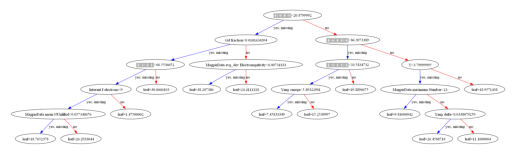

In [7]:
import xgboost as xgb
from xgboost import plot_tree
import matplotlib.pyplot as plt
import joblib
import pandas as pd
# 假设 `bst` 是你的训练好的 XGBoost 模型
# 如果你需要从文件加载模型，可以使用：
# bst = xgb.Booster()
# bst.load_model('model_path')
df = pd.read_excel('../Final_Model/Full.xlsx', index_col=0)
feature_names = df.columns.tolist()

# 模型路径列表
model_paths = [f"../Final_Model/models/kl/xgboost/xgboost{i}.pkl" for i in range(1, 6)]

bst = joblib.load(model_paths[0])

# 绘制第一棵树
plt.figure(figsize=(20, 16),dpi=1000)
plot_tree(bst, num_trees=0)
plt.savefig('kl_xgboost1_vector.svg')  # 保存为 SVG 格式
plt.show()


In [28]:
%pip list
# 使用 pip 安装 matplotlib
!pip install matplotlib
!pip install graphviz


Package                   Version
------------------------- --------
anyio                     4.2.0
argon2-cffi               21.3.0
argon2-cffi-bindings      21.2.0
asttokens                 2.0.5
async-lru                 2.0.4
attrs                     23.1.0
Babel                     2.11.0
beautifulsoup4            4.12.2
bleach                    4.1.0
Bottleneck                1.3.7
Brotli                    1.0.9
certifi                   2024.6.2
cffi                      1.16.0
charset-normalizer        2.0.4
colorama                  0.4.6
comm                      0.2.1
contourpy                 1.2.1
cycler                    0.12.1
debugpy                   1.6.7
decorator                 5.1.1
defusedxml                0.7.1
et-xmlfile                1.1.0
exceptiongroup            1.2.0
executing                 0.8.3
fastjsonschema            2.16.2
fonttools                 4.53.0
idna                      3.7
ipykernel                 6.28.0
ipython                 